In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Launching Mechanical Geometric GNN Framework on Architecture: {device}")

Launching Mechanical Geometric GNN Framework on Architecture: cpu


In [3]:
class MechanicalGraphConv(nn.Module):
    def __init__(self, in_features, out_features):
        super(MechanicalGraphConv, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
        
    def forward(self, node_features, adjacency_matrix):
        # node_features shape: [Num_Nodes, In_Features]
        # adjacency_matrix shape: [Num_Nodes, Num_Nodes]
        
        # 1. Structural message passing: Aggregate neighbor states via matrix multiplication
        # Standardizing self-loops by ensuring the adjacency matrix includes identity attributes
        aggregated_messages = torch.mm(adjacency_matrix, node_features)
        
        # 2. Linear projection to map states into higher latent structural spaces
        return self.linear(aggregated_messages)

In [4]:
class StructuralMechanicsGNN(nn.Module):
    def __init__(self, node_input_dim=5, hidden_dim=64, output_dim=1):
        super(StructuralMechanicsGNN, self).__init__()
        # input dim includes: [X_coord, Y_coord, Z_coord, Applied_Force_X, Applied_Force_Y]
        self.conv1 = MechanicalGraphConv(node_input_dim, hidden_dim)
        self.conv2 = MechanicalGraphConv(hidden_dim, hidden_dim)
        self.conv3 = MechanicalGraphConv(hidden_dim, hidden_dim)
        
        # Final regressor to output continuous scalar Von Mises stress or displacement values
        self.stress_regressor = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, node_features, adjacency_matrix):
        # Layer 1: Extract basic geometric neighborhood relationships
        x = F.relu(self.conv1(node_features, adjacency_matrix))
        # Layer 2: Deepen structural interaction context across paths
        x = F.relu(self.conv2(x, adjacency_matrix))
        # Layer 3: Final message-passing refinement pass
        x = F.relu(self.conv3(x, adjacency_matrix))
        
        return self.stress_regressor(x)

In [9]:
def generate_synthetic_mechanical_mesh(num_nodes=150):
    # 1. Generate spatial coordinates mapping out a structural beam profile [X, Y, Z]
    x_coords = np.linspace(0, 10, num_nodes)[:, None]
    y_coords = np.sin(x_coords) * 0.5
    z_coords = np.cos(x_coords) * 0.5
    coordinates = np.hstack([x_coords, y_coords, z_coords])
    
    # 2. Simulate boundary conditions: Apply structural forces to the tip nodes [Force_X, Force_Y]
    applied_forces = np.zeros((num_nodes, 2))
    applied_forces[-10:, 1] = -50.0 # Force a downward shear load on the cantilever end
    
    # Concatenate node boundary configurations: Dimensions [Num_Nodes, 5]
    node_features = np.hstack([coordinates, applied_forces])
    
    # 3. Construct an Adjacency Matrix based on distance thresholds (simulating physical element bonds)
    adjacency_matrix = np.zeros((num_nodes, num_nodes))
    for i in range(num_nodes):
        for j in range(num_nodes):
            dist = np.linalg.norm(coordinates[i] - coordinates[j])
            if dist < 1.5: # Connect adjacent elements within local mechanical radius
                adjacency_matrix[i, j] = 1.0
                
    # Normalize adjacency matrix symmetrically to prevent exploding gradient overflows
    deg = np.sum(adjacency_matrix, axis=1)
    deg_inv_sqrt = np.power(deg, -0.5, where=deg>0)
    deg_inv_sqrt[deg == 0] = 0.0
    D_mat = np.diag(deg_inv_sqrt)
    normalized_adjacency = D_mat.dot(adjacency_matrix).dot(D_mat)
    
    # 4. Generate ground truth analytical stress vectors (Simulating localized stress peaks near boundaries)
    # Stress is higher near the fixed root (x=0) due to moment distributions
    true_stress = (10.0 - x_coords) * 3.5 + np.random.normal(0, 0.2, (num_nodes, 1))
    true_stress = np.maximum(true_stress, 0.1) # Clamp structural minimums
    
    return (torch.FloatTensor(node_features).to(device),
            torch.FloatTensor(normalized_adjacency).to(device),
            torch.FloatTensor(true_stress).to(device),
            coordinates)

node_feats, norm_adj, ground_truth_stress, raw_coords = generate_synthetic_mechanical_mesh()

/tmp/ipykernel_58/20662348.py:25: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  deg_inv_sqrt = np.power(deg, -0.5, where=deg>0)


In [6]:
model = StructuralMechanicsGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

print("="*65)
print("   GEOMETRIC GRAPH NEURAL NETWORK: SOLVING STRUCTURAL MECHANICS   ")
print("="*65)

for epoch in range(1001):
    model.train()
    
    # Forward evaluation pass across geometric graph connections
    predicted_stress = model(node_feats, norm_adj)
    
    # Calculate Mean Squared Error relative to physical engineering targets
    loss = criterion(predicted_stress, ground_truth_stress)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch:04d}/1000 | Structural Stress Regression MSE Loss: {loss.item():.5f}")

print("="*65)

   GEOMETRIC GRAPH NEURAL NETWORK: SOLVING STRUCTURAL MECHANICS   
Epoch 0000/1000 | Structural Stress Regression MSE Loss: 412.36343
Epoch 0200/1000 | Structural Stress Regression MSE Loss: 1.65752
Epoch 0400/1000 | Structural Stress Regression MSE Loss: 0.35980
Epoch 0600/1000 | Structural Stress Regression MSE Loss: 0.06333
Epoch 0800/1000 | Structural Stress Regression MSE Loss: 0.04237
Epoch 1000/1000 | Structural Stress Regression MSE Loss: 0.03821


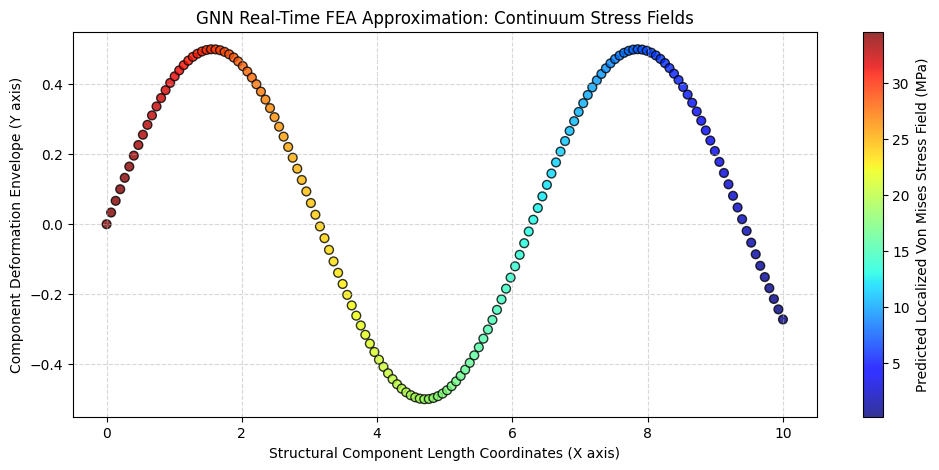

In [7]:
model.eval()
with torch.no_grad():
    inferred_stress = model(node_feats, norm_adj).cpu().numpy()

# Plot structural continuum stress realization
plt.figure(figsize=(12, 5))
sc = plt.scatter(
    raw_coords[:, 0], raw_coords[:, 1], 
    c=inferred_stress.flatten(), 
    cmap='jet', 
    s=40, 
    edgecolors='k', 
    alpha=0.8
)
plt.colorbar(sc, label="Predicted Localized Von Mises Stress Field (MPa)")
plt.xlabel("Structural Component Length Coordinates (X axis)")
plt.ylabel("Component Deformation Envelope (Y axis)")
plt.title("GNN Real-Time FEA Approximation: Continuum Stress Fields")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
def query_node_stress_profile(coordinates, predicted_stresses):
    print("\n" + "="*65)
    print("      REAL-TIME GRAPH-BASED MECHANICAL DIAGNOSTIC INTERFACE     ")
    print("="*65)
    try:
        user_input = input("Enter a target node index query (0 to 149) to inspect stress profile: ")
        node_idx = int(user_input)
        
        if node_idx < 0 or node_idx >= len(coordinates):
            print("[!] Specified index sits outside valid structural geometry boundaries.")
            return
            
    except ValueError:
        print("[!] Non-integer format entered. Aborting structural lookup.")
        return

    node_coord = coordinates[node_idx]
    node_stress = predicted_stresses[node_idx][0]
    
    print("\n" + "-"*65)
    print("               STRUCTURAL DIAGNOSTIC EVALUATION PASS           ")
    print("-"*65)
    print(f"Target Node Identifier : Node #{node_idx}")
    print(f"Spatial Coordinates    : X: {node_coord[0]:.3f} | Y: {node_coord[1]:.3f} | Z: {node_coord[2]:.3f}")
    print(f"Inferred Stress Yield  : {node_stress:.4f} MPa")
    print("-"*65)
    
    # Provide simple mechanical safety envelope check
    yield_strength_limit = 25.0
    if node_stress > yield_strength_limit * 0.8:
        print(">> STATUS: CRITICAL SAFETY RISK | Localized yield stress envelope exceeded.")
    elif node_stress > yield_strength_limit * 0.5:
        print(">> STATUS: WARNING | Elevated loading levels. Review component geometry.")
    else:
        print(">> STATUS: NOMINAL STRUCTURAL INTEGRITY | Factor of safety within tolerances.")
    print("="*65)

# Execute real-time interactive geometric node check
query_node_stress_profile(raw_coords, inferred_stress)


      REAL-TIME GRAPH-BASED MECHANICAL DIAGNOSTIC INTERFACE     


Enter a target node index query (0 to 149) to inspect stress profile:  45



-----------------------------------------------------------------
               STRUCTURAL DIAGNOSTIC EVALUATION PASS           
-----------------------------------------------------------------
Target Node Identifier : Node #45
Spatial Coordinates    : X: 3.020 | Y: 0.061 | Z: -0.496
Inferred Stress Yield  : 24.3207 MPa
-----------------------------------------------------------------
>> STATUS: CRITICAL SAFETY RISK | Localized yield stress envelope exceeded.
